In [1459]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, sosfiltfilt, sosfilt
from scipy.sparse import lil_matrix
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from dataclasses import dataclass
import random
import time

from scipy.optimize import least_squares

def print_err_stats(x, gt, center=False, prefix=""):
    if center:
        x = x - np.mean(x)
        gt = gt - np.mean(gt)
    error = x - gt
    rmse = np.mean(error ** 2) ** 0.5
    mae = np.mean(abs(error))
    me = np.mean(error)
    print(f"{prefix} RMSE: {rmse:.3f}, MAE: {mae:.3f}, ME: {me:.3f}")
    return rmse, mae, me

In [ ]:
log_filename = "log029_filtered"
out_dir = f"backend/run_artifacts/{log_filename}/cache/"
ws_file = out_dir + "/all.npz"
ws = np.load(ws_file)
print([str(key) for key in ws.keys()])

travel = ws["travel__x"][:, 0]
t = ws["accel/lpf/proj__t"]
acc = ws["accel/lpfhp/proj__x"][:, 0] * 1000
mag = ws["mag/proj/lpf__x"][:, 0]
mag_zv_points = ws["mag_zv_points"]
ref_x, ref_mag = ws["mag_travel_ref_point"]
dense_mag_zv = np.zeros_like(acc)
dense_mag_zv[mag_zv_points] = 1
mag_pred_x = ws["travel/mag_model__x"][:, 0]
dt_s = np.diff(t, prepend=t[0]-0.01)
v_gt = np.diff(travel, prepend=travel[0]) / dt_s

print(acc.shape)
print(mag.shape)
print(travel.shape)
print(mag_zv_points.shape)
#print(mag_thresholds)
print(mag_pred_x.shape)

#print(min(mag_pred_x[mag_in_bounds_mask]), max(mag_pred_x[mag_in_bounds_mask]))

#roi = slice(8000, 9000) #log022 cal pulses
#roi = slice(52000, 53000)
#roi = slice(14500, 15000) #spike in log029
#roi = slice(10000, 20000)
roi=None

if roi is not None:
    t = t[roi]
    acc = acc[roi]
    mag = mag[roi]
    travel = travel[roi]
    #mag_in_bounds_mask = mag_in_bounds_mask[roi]
    mag_pred_x = mag_pred_x[roi]
    v_gt = v_gt[roi]
    dense_mag_zv = dense_mag_zv[roi]

    print(acc.shape)
    print(mag.shape)
    print(travel.shape)
    #print(mag_thresholds)
    print(mag_pred_x.shape)
    print(np.count_nonzero(dense_mag_zv))
    print(np.where(dense_mag_zv)[0])

num_samp = acc.shape[0]

['accel/lis1__t', 'accel/lis1__x', 'accel/lis2__t', 'accel/lis2__x', 'mag__t', 'mag__x', 'angle__t', 'angle__x', 'accel/lpf/lis1__t', 'accel/lpf/lis1__x', 'accel/lpf/lis2__t', 'accel/lpf/lis2__x', 'rotation_matrix', 'accel/lis2_in_lis1__t', 'accel/lis2_in_lis1__x', 'accel/relative__t', 'accel/relative__x', 'accel/lpf/relative__t', 'accel/lpf/relative__x', 'accel_trav_vec', 'mags_vs_means', 'accel/proj__t', 'accel/proj__x', 'accel/lpf/proj__t', 'accel/lpf/proj__x', 'accel/lpfhp/proj__t', 'accel/lpfhp/proj__x', 'angle/lpf__t', 'angle/lpf__x', 'travel__t', 'travel__x', 'mag/proj__t', 'mag/proj__x', 'mag/proj/lpf__t', 'mag/proj/lpf__x', 'mag/lpf__t', 'mag/lpf__x', 'mag/proj/lpf/corr__t', 'mag/proj/lpf/corr__x', 'mag/proj/lpf/bad_mask__t', 'mag/proj/lpf/bad_mask__x', 'mag_zv_points', 'mag_travel_ref_point', 'travel/mag_model__t', 'travel/mag_model__x', 'fusion_scatter_points']
(32605,)
(32605,)
(32605,)
(939,)
(32605,)


In [1461]:
# Create and define weights
@dataclass
class Weights:
    v0: float = 40      # prior on v0 (m/s)
    x0: float = 5e2      # prior on x0 (m)
    mag_x: float = 200  # position anchor std (m)     (smaller = stronger mag)
    mag_x_thresh: float = 500 # threshold for applying mag_x weight (mG)
    zupt_v: float = 80  # velocity at ZUPT std (m/s)  (smaller = stronger ZUPT)
    b: float = 1      # bias penalty (m/s^2)


In [1462]:
# Define residual

def calculate_res(vec, w):
    N = num_samp
    x = vec[:N]
    v = vec[N:2*N]
    b = vec[2*N]  # <-- add bias as last variable
    bx = vec[2*N+1]

    dt = t[1:] - t[:-1]          # (N-1,)
    a  = acc[:N-1] - b           # (N-1,)

    acc_v = v[:-1] + a * dt      # predicts v[1:] from v[:-1]  -> (N-1,)
    acc_x = x[:-1] + v[:-1]*dt + 0.5 * a * dt**2   # predicts x[1:] -> (N-1,)

    v_res = acc_v - v[1:]        # (N-1,)
    x_res = acc_x - x[1:]        # (N-1,)

    mag_res_mask = ((mag[1:] > w.mag_x_thresh) + 1) / 2
    mag_pred_res = (mag_pred_x[1:] - x[1:] - bx) * mag_res_mask  # (N-1,)

    # zv_res = v[i] if dense_mag_zv[i] else 0, for i=1..N-1
    zv_res = dense_mag_zv[1:] * v[1:]   # works if dense_mag_zv is bool or 0/1  -> (N-1,)

    res = np.zeros((4, N), dtype=float)
    res[0, 1:] = v_res * w.v0
    res[1, 1:] = x_res * w.x0
    res[2, 1:] = mag_pred_res * w.mag_x
    res[3, 1:] = zv_res * w.zupt_v

    #r = res[:, 1:].flatten()
    r = np.concatenate((res[:, 1:].ravel(order="F"), [b * w.b]))
    return r

guess_vec = np.zeros((num_samp * 2 + 2,))
guess_vec[:num_samp] = mag_pred_x  # initial guess for x is the mag pred
guess_vec[num_samp:num_samp*2] = np.cumsum(acc) * np.mean(dt_s)  # initial guess for v is just integrating accel
guess_vec[-1] = 0  # initial guess for bias
foo = time.time()
w = Weights()
res = calculate_res(guess_vec, w)
print(time.time() - foo)
print(np.mean(res), np.std(res))

0.006658792495727539
-81.49895025142004 2092.887797111782


In [1463]:
def make_jac_sparsity(N, n_res_per_step=4, include_bias=True, include_bias_penalty=True):
    # z = [x(0..N-1), v(0..N-1), b]
    n_var = 2*N + 1 + (1 if include_bias else 0)

    n_steps = N - 1
    n_res = n_res_per_step * n_steps + (1 if (include_bias and include_bias_penalty) else 0)

    J = lil_matrix((n_res, n_var), dtype=bool)

    def ix_x(i): return i
    def ix_v(i): return N + i
    ix_b = 2*N
    ix_bx = 2*N+1 # last variable

    for i in range(1, N):
        # This assumes your residual vector is packed as:
        # [step1(4 entries), step2(4 entries), ..., stepN-1(4 entries), bias_penalty]
        r0 = (i - 1) * n_res_per_step

        # v_dyn at step i depends on v[i], v[i-1], b
        J[r0 + 0, ix_v(i)] = True
        J[r0 + 0, ix_v(i - 1)] = True
        if include_bias:
            J[r0 + 0, ix_b] = True

        # x_dyn depends on x[i], x[i-1], v[i-1], b
        J[r0 + 1, ix_x(i)] = True
        J[r0 + 1, ix_x(i - 1)] = True
        J[r0 + 1, ix_v(i - 1)] = True
        if include_bias:
            J[r0 + 1, ix_b] = True
        J[r0 + 1, ix_bx] = True

        # mag anchor depends on x[i] (even if gated to 0, keep structure)
        J[r0 + 2, ix_x(i)] = True
        J[r0 + 2, ix_bx] = True

        # zupt depends on v[i] (even if gated)
        J[r0 + 3, ix_v(i)] = True

    # Final residual: b*w.b depends only on b
    if include_bias and include_bias_penalty:
        J[n_res - 1, ix_b] = True

    return J.tocsr()

In [1464]:
# Run the solver
Jsp = make_jac_sparsity(num_samp, include_bias=True)

loop_params = True
w = Weights()

rmse_travel_min = 0
thresh_mask = travel > rmse_travel_min
print("Error travel threshold:", rmse_travel_min, "using", np.sum(thresh_mask), "samples for error stats")

def train(weights):
    result = least_squares(
        fun=calculate_res,
        x0=guess_vec, 
        jac_sparsity=Jsp, 
        jac="2-point",
        method="trf",
        x_scale="jac",
        verbose=1,
        max_nfev=1000,
        args=(weights,)
    )
    return result

if loop_params:
    error_vec = []  
    for scale in [0.25, 0.5, 2, 4]:
        for weight in Weights.__dataclass_fields__:
            weight_dict = w.__dict__.copy()  # copy original weights
            weight_dict[weight] *= scale  # example modification: scale each weight by the current factor
            mod_weights = Weights(**weight_dict)  # create a new Weights instance with original values
            print()
            print(weight, "=", weight_dict[weight])
            result = train(mod_weights)
            res_x = result.x[:num_samp]
            res_v = result.x[num_samp:num_samp*2]
            res_b = result.x[-1]
            rmse_x, _, _ = print_err_stats(res_x[thresh_mask], travel[thresh_mask], prefix="Position (centered)", center=True)
            rmse_v, _, _ = print_err_stats(res_v[thresh_mask], v_gt[thresh_mask], prefix="Velocity")
            error_vec.append([rmse_x, weight, weight_dict[weight], res_x, res_v])

    best_errors = sorted(error_vec, key=lambda x: x[0])[:5]
    print("\nBest 5 results:")
    for rmse, weight_name, weight_value, _, _ in best_errors:
        print(f"Weight: {weight_name}, Value: {weight_value}, RMSE: {rmse:.3f}")

    res_x, res_v = best_errors[0][3:5]
else:
    result = train(w)
    res_x = result.x[:num_samp]
    res_v = result.x[num_samp:num_samp*2]
    res_b = result.x[-2]
    res_offset = result.x[-1]
    res_residual = result.fun

Error travel threshold: 0 using 32271 samples for error stats

v0 = 10.0
`ftol` termination condition is satisfied.
Function evaluations 4, initial cost 1.6801e+11, final cost 4.1037e+09, first-order optimality 2.78e+01.
Position (centered) RMSE: 7.260, MAE: 5.968, ME: 0.000
Velocity RMSE: 124.186, MAE: 63.685, ME: -0.057

x0 = 125.0
`ftol` termination condition is satisfied.
Function evaluations 6, initial cost 2.5552e+11, final cost 1.3150e+10, first-order optimality 3.26e+01.
Position (centered) RMSE: 7.465, MAE: 6.063, ME: 0.000
Velocity RMSE: 182.254, MAE: 97.484, ME: 0.853

mag_x = 50.0
`ftol` termination condition is satisfied.
Function evaluations 5, initial cost 2.8606e+11, final cost 1.4456e+10, first-order optimality 4.85e+01.
Position (centered) RMSE: 7.932, MAE: 6.385, ME: -0.000
Velocity RMSE: 158.952, MAE: 81.354, ME: 1.672

mag_x_thresh = 125.0
`ftol` termination condition is satisfied.
Function evaluations 4, initial cost 2.8606e+11, final cost 2.0579e+10, first-order 

Position > 0 RMSE: 9.301, MAE: 7.135, ME: -5.992
Position > 0 (centered) RMSE: 7.113, MAE: 5.903, ME: 0.000

Velocity RMSE: 165.443, MAE: 86.159, ME: 1.425
Position RMSE: 9.267, MAE: 7.113, ME: -5.983
Position (centered) RMSE: 7.077, MAE: 5.851, ME: 0.000
Bias: 0.3134738312029866, Offset: 0.04309496225752309


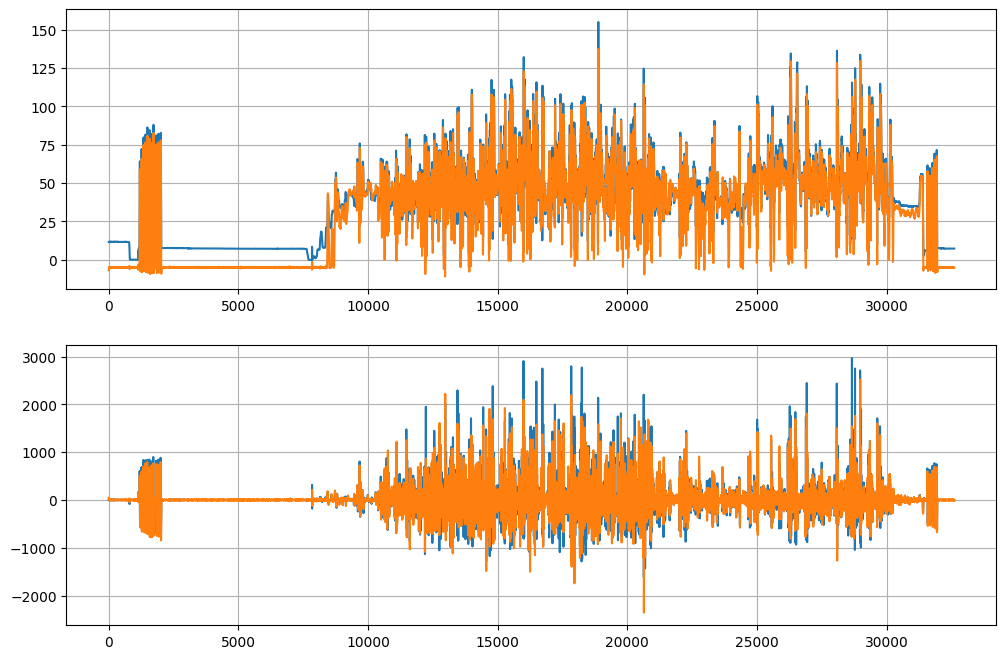

In [1465]:
if loop_params:
    res_x, res_v = best_errors[0][3:5]

plt.figure(figsize=(12,8))
plt.subplot(2, 1, 1)
plt.plot(travel)
plt.plot(res_x)
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(v_gt)
plt.plot(res_v)
plt.grid()

print_err_stats(res_x[thresh_mask], travel[thresh_mask], prefix=f"Position > {rmse_travel_min}")
print_err_stats(res_x[thresh_mask], travel[thresh_mask], center=True, prefix=f"Position > {rmse_travel_min} (centered)")
print()
print_err_stats(res_v, v_gt, prefix="Velocity")
res_x_cent = res_x - np.mean(res_x)  # align to start
travel_cent = travel - np.mean(travel)
print_err_stats(res_x, travel, prefix="Position")
print_err_stats(res_x_cent, travel_cent, prefix="Position (centered)")
print(f"Bias: {res_b}, Offset: {res_offset}")


In [1466]:
# Give RMSE in different travel ranges
for travel_min in range(0, 150, 30):
    travel_max = travel_min + 30
    mask = (travel >= travel_min) & (travel < travel_max)
    print(f"\nTravel range: {travel_min} to {travel_max} mm, samples: {np.count_nonzero(mask)}")
    print_err_stats(res_x_cent[mask], travel_cent[mask], prefix="Position (centered)")
    print_err_stats(res_x[mask], travel[mask], prefix="Position")
    print_err_stats(res_v[mask], v_gt[mask], prefix="Velocity")



Travel range: 0 to 30 mm, samples: 10841
Position (centered) RMSE: 7.851, MAE: 7.021, ME: -6.123
Position RMSE: 13.065, MAE: 12.394, ME: -12.106
Velocity RMSE: 93.565, MAE: 33.793, ME: -17.066

Travel range: 30 to 60 mm, samples: 15957
Position (centered) RMSE: 7.193, MAE: 5.912, ME: 3.736
Position RMSE: 6.545, MAE: 4.239, ME: -2.247
Velocity RMSE: 166.718, MAE: 96.797, ME: -4.031

Travel range: 60 to 90 mm, samples: 4703
Position (centered) RMSE: 4.814, MAE: 3.572, ME: 1.522
Position RMSE: 6.384, MAE: 4.836, ME: -4.461
Velocity RMSE: 244.622, MAE: 152.975, ME: 44.615

Travel range: 90 to 120 mm, samples: 744
Position (centered) RMSE: 5.945, MAE: 3.919, ME: -0.520
Position RMSE: 8.795, MAE: 6.748, ME: -6.503
Velocity RMSE: 285.464, MAE: 206.055, ME: 97.110

Travel range: 120 to 150 mm, samples: 75
Position (centered) RMSE: 6.408, MAE: 4.184, ME: -3.004
Position RMSE: 10.621, MAE: 9.038, ME: -8.987
Velocity RMSE: 392.515, MAE: 297.637, ME: 173.840


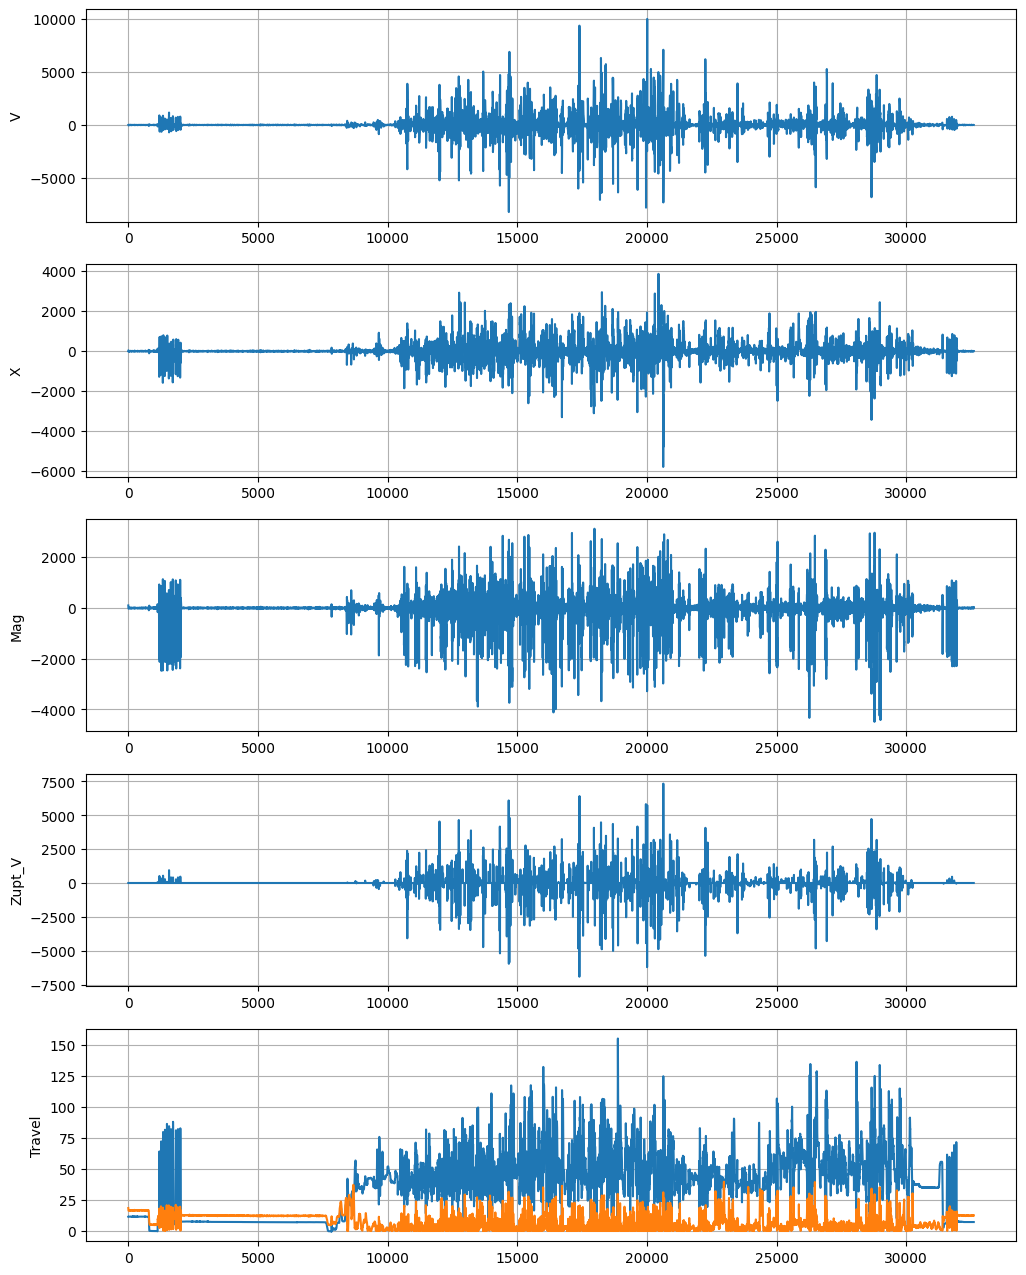

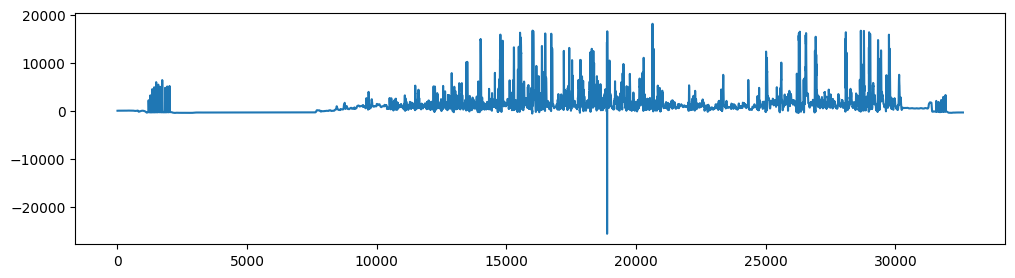

In [1467]:
# Plot each residual
def plot_ress(res_i):
    plt.figure(figsize=(12, 16))
    for i, label in enumerate(["V", "X", "Mag", "Zupt_V"]):
        plt.subplot(5, 1, i+1)
        plt.plot([res_i[i + j * 4] for j in range(num_samp - 1)])
        plt.grid()
        plt.ylabel(label)
    plt.subplot(5, 1, 5)
    plt.plot(travel)
    plt.ylabel("Travel")

res_i = result.fun
plot_ress(res_i)
plt.plot(abs(res_x - travel))
plt.grid()
plt.figure(figsize=(12,3))
plt.plot(mag)

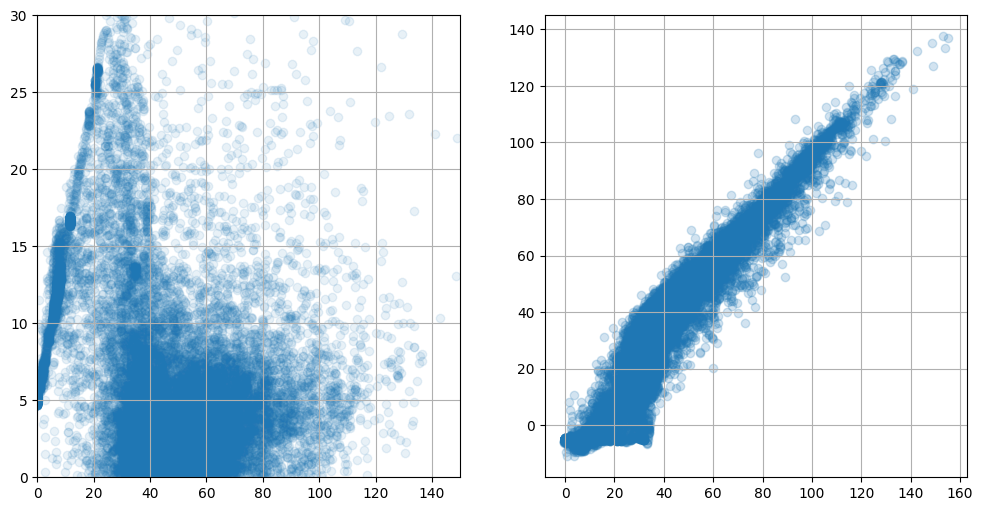

In [1468]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.scatter(travel, abs(res_x - travel), alpha=0.1)
plt.ylim(0, 30)
plt.xlim(0, 150)
plt.grid()
plt.subplot(1, 2, 2)
plt.scatter(travel, res_x, alpha=0.2)
plt.grid()
plt.show()


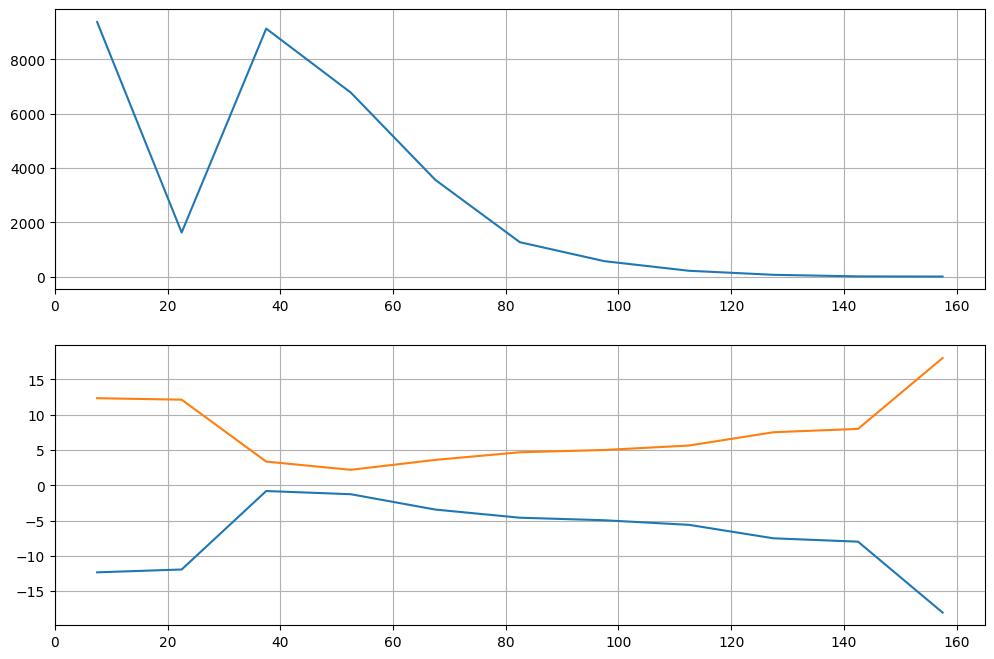

In [1469]:

# histogram of error binned by travel
bin_size = 15
mag_min = np.min(travel)
mag_max = np.max(travel)
num_bins = int(np.ceil((mag_max - mag_min) / bin_size))
bins = [[] for _ in range(num_bins)]
for i in range(len(travel)):
    bin_idx = int((travel[i] - mag_min) / bin_size)
    if 0 <= bin_idx < num_bins:
        bins[bin_idx].append(res_x[i] - travel[i])

plt.figure(figsize=(12,8))
plt.subplot(2, 1, 1)
plt.plot([bin_size * (i + 0.5) for i in range(len(bins))], [len(bin) for bin in bins])
plt.grid()
plt.subplot(2, 1, 2)
plt.plot([bin_size * (i + 0.5) for i in range(len(bins))], [np.median(bin) for bin in bins])
plt.plot([bin_size * (i + 0.5) for i in range(len(bins))], [np.median([abs(x) for x in bin]) for bin in bins])
plt.grid()
plt.show()